# 🧠 Convolution and Edge Detection in Computer Vision

## 🔹 What is Convolution?

**Convolution** is a key operation in Convolutional Neural Networks (CNNs), especially used for **feature extraction** like detecting **edges, textures, patterns**, etc., in images.

It involves sliding a small matrix called a **kernel** or **filter** over the input image and performing **element-wise multiplication** followed by **summation** at each position.

---

## 🔹 Biological Analogy: V1 Region in Human Brain

- The **V1 area** of the **visual cortex** is responsible for detecting **edges** in visual input.
- Inspired by this biological system, CNNs use convolution layers to extract edges from images.

---

## 🔹 Example: Edge Detection using Convolution

### Let's say we have a grayscale image of size **6×6** (only 1 channel):


### Convolution Operation (Stride=1, No Padding)

**Input Image (6×6):**

$$
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 \\
255 & 255 & 255 & 255 & 255 & 255 \\
255 & 255 & 255 & 255 & 255 & 255 \\
255 & 255 & 255 & 255 & 255 & 255 \\
\end{bmatrix}
$$

**Kernel (3×3):**

$$
\begin{bmatrix}
+1 & +2 & +1 \\
0 & 0 & 0 \\
-1 & -2 & -1 \\
\end{bmatrix}
$$

### Output Feature Map Size:

With no padding and stride = 1:  
$$
\text{Output size} = (6 - 3 + 1) \times (6 - 3 + 1) = 4 \times 4
$$

---

### Step-by-step Element-wise Multiplication and Summation

We slide the kernel over each 3×3 patch of the image, compute element-wise multiplication, then sum all values.

---

#### **Output[0][0]**

Patch:
$$
\begin{bmatrix}
0 & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & 0 \\
\end{bmatrix}
$$

Multiplication:
$$
0+0+0+0+0+0+0+0+0 = \boxed{0}
$$

---

#### **Output[0][1]**

Patch:
$$
\begin{bmatrix}
0 & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & 0 \\
\end{bmatrix}
$$

Same as above → $(\boxed{0}$)

---

#### **Output[0][2]**

Same → $(\boxed{0}$)

---

#### **Output[0][3]**

Same → $(\boxed{0}$)

---

#### **Output[1][0]**

Patch:
$$
\begin{bmatrix}
0 & 0 & 0 \\
0 & 0 & 0 \\
255 & 255 & 255 \\
\end{bmatrix}
$$

Multiplication:
$$
(0×1) + (0×2) + (0×1) + (0×0) + (0×0) + (0×0) + (255×(-1)) + (255×(-2)) + (255×(-1)) = 0 + 0 + 0 + 0 + 0 + 0 -255 -510 -255 = \boxed{-1020}
$$

---

#### **Output[1][1]**

Patch:
$$
\begin{bmatrix}
0 & 0 & 0 \\
0 & 0 & 0 \\
255 & 255 & 255 \\
\end{bmatrix}
$$

Same as above → $(\boxed{-1020}$)

---

#### **Output[1][2]**

Same → $(\boxed{-1020}$)

---

#### **Output[1][3]**

Same → $(\boxed{-1020}$)

---

#### **Output[2][0]**

Patch:
$$
\begin{bmatrix}
0 & 0 & 0 \\
255 & 255 & 255 \\
255 & 255 & 255 \\
\end{bmatrix}
$$

Multiplication:
$$
0 + 0 + 0 + 0 + 0 + 0 -255 -510 -255 = \boxed{-1020}
$$

---

#### **Output[2][1]**

Same → $(\boxed{-1020}$)

---

#### **Output[2][2]**

Same → $(\boxed{-1020}$)

---

#### **Output[2][3]**

Same → $(\boxed{-1020}$)

---

#### **Output[3][0]**

Patch:
$$
\begin{bmatrix}
255 & 255 & 255 \\
255 & 255 & 255 \\
255 & 255 & 255 \\
\end{bmatrix}
$$

Multiplication:
$$
(255×1) + (255×2) + (255×1) + 0 + 0 + 0 + (255×(-1)) + (255×(-2)) + (255×(-1)) \\
= 255 + 510 + 255 + 0 + 0 + 0 -255 -510 -255 = \boxed{0}
$$

---

#### **Output[3][1] to Output[3][3]**

Same patch values → $(\boxed{0}$)

---

### Final Output Feature Map (4×4):

$$
\begin{bmatrix}
0 & 0 & 0 & 0 \\
-1020 & -1020 & -1020 & -1020 \\
-1020 & -1020 & -1020 & -1020 \\
0 & 0 & 0 & 0 \\
\end{bmatrix}
$$


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

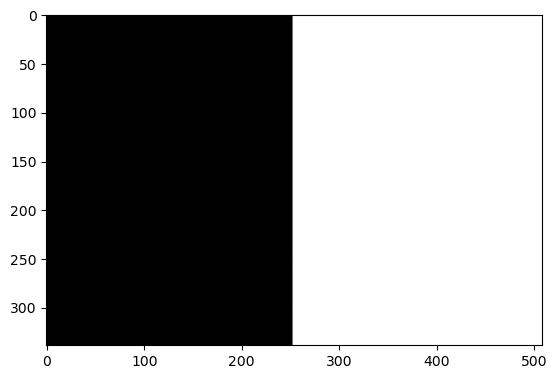

In [5]:
image_path = r"D:\cv\02\Image.jpg"
image = cv2.imread(image_path)

img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [6]:
image_path = r"D:\cv\02\Image.jpg"

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
# image

In [7]:
sobel_vertical = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]])
sobel_vertical

array([[-1,  0,  1],
       [-2,  0,  2],
       [-1,  0,  1]])

In [8]:
image.shape

(339, 509)

In [9]:
rows, cols = image.shape
rows, cols

(339, 509)

In [10]:
k = sobel_vertical.shape[0]
k

3

In [11]:
output_matrix = np.zeros((rows - k + 1, cols - k + 1))
output_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [12]:
for i in range(1, rows-1):
    for j in range(1, cols-1):
        region = image[i-1:i+2, j-1:j+2]
        output_matrix[i-1, j-1] = np.sum(region * sobel_vertical)

In [13]:
output_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

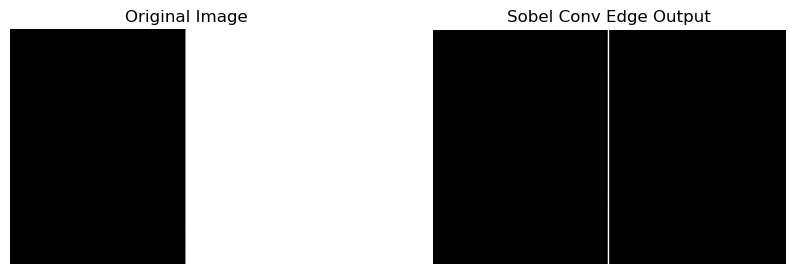

In [14]:
import matplotlib.pyplot as plt
plt.figure = plt.figure(figsize = (10,5))

# original image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap= 'gray')
plt.axis('off')


plt.subplot(1, 2, 2)
plt.title("Sobel Conv Edge Output")
plt.imshow(output_matrix, cmap = 'gray')
plt.axis('off')

plt.show()

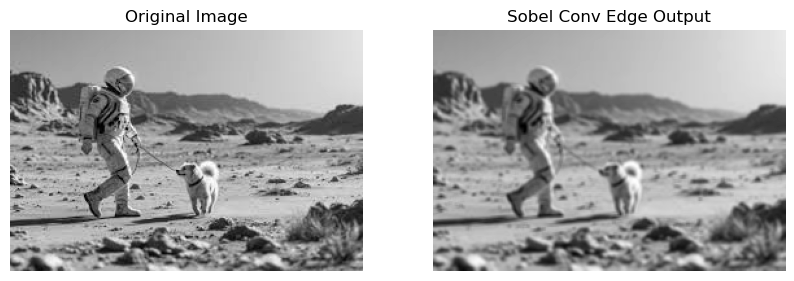

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image_path = r"C:\Users\goura\Downloads\images.jpg"

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

sobel_vertical = np.array([[+1, +2, +1],
                           [0, 0, 0],
                           [-1, -2, -1]])

sobel_vertical = np.array([[1/9, 1/9, 1/9],
                           [1/9, 1/9, 1/9],
                           [1/9, 1/9, 1/9]])
sobel_vertical

sobel_output = cv2.filter2D(image, -1, sobel_vertical)
sobel_output.shape


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# original image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Sobel Conv Edge Output
plt.subplot(1, 2, 2)
plt.title("Sobel Conv Edge Output")
plt.imshow(sobel_output, cmap='gray')
plt.axis('off')

plt.show()


## 🔹 Output Image Size

When performing convolution:

- **Input image size** = $( n \times n $)
- **Kernel size** = $( k \times k $)

Then the **Output size** is given by:

$$
\text{Output Size} = (n - k + 1) \times (n - k + 1)
$$

**Example:**

$$
6 \times 6 \text{ image} \quad \& \quad 3 \times 3 \text{ kernel} \Rightarrow \text{Output size} = 4 \times 4
$$

---

## 🔹 Post-Processing: Normalization

After applying a kernel, pixel values may go beyond the normal grayscale range \([0, 255]\).

To bring them back into this range, **Normalization** is applied:

$$
\text{Normalized Value} = \frac{\text{Pixel} - \text{Min}}{\text{Max} - \text{Min}} \times 255
$$

This ensures the output image is properly scaled for visualization or further processing.

---

## 🔹 Why Convolution is Great for Edge Detection

- **Local Feature Extraction**: Each kernel focuses on a small patch of the image, enabling localized pattern detection.
- **Translation Invariance**: The same kernel slides across the entire image, making detection robust to position shifts.
- **Efficient Computation**: Fewer parameters than fully connected layers, making it memory and compute efficient.

---

## 🔹 Common Edge Detection Filters

| **Filter Type**       | **Kernel Example**                                         | **Detects**          |
|-----------------------|------------------------------------------------------------|----------------------|
| **Sobel (Horizontal)**| $(\begin{bmatrix} +1 & +2 & +1 \\ 0 & 0 & 0 \\ -1 & -2 & -1 \end{bmatrix}$)| Horizontal Edges     |
| **Sobel (Vertical)**  |  $(\begin{bmatrix} +1 & 0 & -1 \\ +2 & 0 & -2 \\ +1 & 0 & -1 \end{bmatrix}$) | Vertical Edges       |
| **Prewitt**           | Similar to Sobel but with uniform weights                  | Horizontal/Vertical  |
| **Laplacian**         | Uses second-order derivatives                              | All directional edges|

---

## 🔹 Is Kernel Size Always 3×3?

No. While **3×3** is most common, other sizes are also used:

- Common sizes: **3×3**, **5×5**, **7×7**
- Shape: Usually square, but rectangular kernels are also possible
- Trade-off:
  - **Larger kernels** capture **broader features**
  - But they also require **more computation**


# Padding

### Padding in Convolutional Neural Networks

**Padding** refers to the practice of adding extra pixels (usually with a value of zero) around the border of an input image before applying the convolution operation. This helps in controlling the **spatial dimensions** of the output feature map.

---

### 🔶 Why is Padding Required?

1. **Maintain Image Dimensions**  
   Without padding, the size of the output feature map decreases after each convolution. Padding helps **preserve the original spatial dimensions**, enabling deeper networks without shrinking the image too much.

2. **Preserve Edge Information**  
   Padding ensures that filters can be applied to **edge pixels** of the image, preserving crucial boundary information that might otherwise be lost.

3. **Control Feature Map Size**  
   Padding allows us to **customize the output size**, which is important for consistent network design.

---

### 🔹 Types of Padding

#### 1. **Valid Padding (No Padding)**
- No extra pixels are added.
- Filter is applied **only to valid positions**.
- Output size is **reduced**.
- **Formula**:  
  $$
  \text{Output Size} = \left[\frac{(n - f + 1)}{s}\right]
  $$
- **Example**:  
  Input = 5×5, Filter = 3×3 → Output = 3×3

---

#### 2. **Same Padding**
- Padding is added to maintain the **same size** of the output as the input.
- Output size = Input size.
- **Formula**:  
  $$
  \text{Output Size} = \left[\frac{n}{s}\right]
  $$
  (with appropriate padding `p`)
- **Example**:  
  Input = 5×5, Filter = 3×3 → Output = 5×5

---

#### 3. **Full Padding**
- Adds **enough padding** so that filter can be applied to every pixel, even beyond borders.
- Output size is **larger** than the input.
- **Example**:  
  Input = 5×5, Filter = 3×3 → Output = 7×7

---

### 🔸 Padding Techniques

| Technique            | Description                                                                 |
|----------------------|-----------------------------------------------------------------------------|
| **Zero Padding**      | Most common; fills padding with zeros.                                      |
| **Reflection Padding** | Padding mirrors the boundary pixels.                                        |
| **Replication Padding**| Replicates the nearest boundary pixels.                                     |
| **Constant Padding**   | Fills padding with a constant value (e.g., 1, -1, etc.).                    |

---

### 🧮 Key Terms

- `n`: Input image size (e.g., 5×5)
- `f`: Filter (kernel) size (e.g., 3×3)
- `s`: Stride (step size of the kernel)
- `p`: Padding size (pixels added to each side)

---

### 📌 Output Size Formulas

1. **Without Padding (Valid):**
   $$
   \text{Output} = (n - f + 1) \times (n - f + 1)
   $$

2. **With Padding:**
   $$
   \text{Output} = (n - f + 2p + 1) \times (n - f + 2p + 1)
   $$

---

### 🧠 Summary

Padding is essential in CNNs to maintain spatial resolution, retain edge features, and control network design. Using the right type and amount of padding ensures efficient learning and better performance, especially in deep networks.


# Stride
## Stride in Convolutional Neural Networks

**Stride** refers to the step size by which a convolution filter moves across the input image or feature map during the convolution operation.

---

### 📌 Key Points about Stride

#### 1. **Stride Size (s)**

- A stride is a positive integer.
- **Stride = 1**: The filter moves one pixel at a time.
- **Stride = 2**: The filter jumps two pixels at a time, skipping one.

#### 2. **Effect on Output Size**

- **Larger Strides**: Reduce the output feature map size since the filter covers fewer positions.
- **Smaller Strides**: Increase overlap between adjacent receptive fields and produce a larger output.

The output size can be calculated as:

$$
\text{Output Size} = \left\lfloor \frac{n - k + 2p}{s} \right\rfloor + 1
$$

Where:
- $(n$): Input size (height or width)
- $(k$): Kernel/filter size
- $(p$): Padding
- $(s$): Stride

---

### 📌 Impact on Receptive Field

- **Smaller strides** → More overlap between receptive fields → More detailed output
- **Larger strides** → Less overlap → More compressed output, less spatial detail

---

### 📌 Stride in Different Dimensions

| Type         | Description                                  |
|--------------|----------------------------------------------|
| **1D Stride**| Used in sequence models, time-series data    |
| **2D Stride**| Used in image data (height and width)        |
| **3D Stride**| Used in volumetric/video data (depth too)    |

---

### 📌 Implications of Stride

#### ➤ Smaller Stride:
- Retains more spatial info
- Higher number of operations
- Output size close to input

#### ➤ Larger Stride:
- Reduces details, focuses on higher-level features
- Fewer operations
- Smaller output

---

### 📌 Practical Considerations

- **Stride = 1**: Common in early CNN layers to capture fine details
- **Stride > 1**: Used in deeper layers or when downsampling is needed (e.g., in pooling)

---

### 🧮 Summary Formula

- **Without Padding**:  
  $$
  \text{Output} = \left\lfloor \frac{n - k}{s} \right\rfloor + 1
  $$

- **With Padding (p)**:  
  $$
  \text{Output} = \left\lfloor \frac{n - k + 2p}{s} \right\rfloor + 1
  $$

---


# Pooling
## Pooling in Convolutional Neural Networks (CNNs)

**Pooling** is a downsampling technique used in CNNs to reduce the spatial dimensions (height and width) of feature maps. It helps in summarizing features, reducing computation, and improving robustness to small distortions or translations in input images.

---

### 🔍 Why is Pooling Important?

1. **Dimensionality Reduction**  
   - Reduces the number of parameters and computations in the network.  
   - Helps prevent overfitting.

2. **Focus on Dominant Features**  
   - Retains important features like edges and textures.  
   - Discards less informative background noise.

3. **Translation Invariance**  
   - Makes the model more robust to slight shifts or distortions in input images.

---

### 🧩 Types of Pooling

#### 1. **Max Pooling**
- **Operation**: Selects the **maximum value** from each region covered by the pooling window.
- **Purpose**: Captures the most significant feature (e.g., strong edges or activations).

**Example**:
**Input Patch:**  
$$
\begin{bmatrix}
1 & 3 \\
2 & 4
\end{bmatrix}
$$ 
**→ Max Pool:** 4



---

#### 2. **Average Pooling**
- **Operation**: Computes the **average** of values in the pooling window.
- **Purpose**: Produces a smoother output by reducing noise and preserving average context.

**Example**:
**Input Patch:**  
$$
\begin{bmatrix}
1 & 3 \\
2 & 4
\end{bmatrix}
$$ 
**→ Average Pool:** $(\frac{1 + 3 + 2 + 4}{4} = 2.5$)


---

#### 3. **Global Pooling**

Applies pooling over the **entire feature map**, reducing it to a single value per feature map.

- **Global Average Pooling**:  
  Takes the average of the entire map.

- **Global Max Pooling**:  
  Takes the maximum value from the entire map.

**Purpose**:
- Reduces each feature map to a single scalar.
- Used before fully connected layers, especially in classification tasks.

**Example**:
A 4×4 feature map → 1 value after Global Average or Max Pooling.

---

#### 4. **L2 Pooling**
- **Operation**: Computes the L2 norm (square root of sum of squares) for values in a pooling region.

$$
\text{L2 Pool} = \sqrt{x_1^2 + x_2^2 + \dots + x_n^2}
$$

- **Purpose**: Retains information about feature magnitudes. Less commonly used, but useful when energy-based information is needed.

**Example**:
**Input Patch:** $([1, 3, 2, 4]$)  
**→ L2 Pool:** $(sqrt{1^2 + 3^2 + 2^2 + 4^2} = \sqrt{30}$)


---

### ✅ Pooling in Practice

| Pooling Type        | Common Use Case |
|---------------------|------------------|
| **Max Pooling**     | Most common; emphasizes strong features (edges, textures) |
| **Average Pooling** | Useful when smoothing or noise reduction is desired |
| **Global Pooling**  | Classification tasks before dense layers |
| **L2 Pooling**      | Specialized tasks needing feature energy representation |

---

### 🧠 Global Max Pooling 2D

- Selects the maximum value from the **entire 2D feature map**, regardless of location.
- Reduces each feature map to **1 scalar value**.
- **Use Case**: Especially helpful in classification tasks where the *presence* of a feature matters more than *where* it occurs.

---

### 📌 Summary

Pooling layers:
- Help control overfitting
- Reduce computational load
- Preserve essential spatial features
- Enable hierarchical abstraction in CNNs


# Convolution from scratch

In [3]:
import numpy as np
image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 2],
    [3, 0, 1, 2, 1],
    [2, 1, 3, 0, 0],
    [1, 2, 0, 1, 2]
])

image.shape

(5, 5)

In [4]:
5-3+1, 5-3+1

(3, 3)

In [5]:
import numpy as np

# Define a simple 5x5 grayscale image
image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 2],
    [3, 0, 1, 2, 1],
    [2, 1, 3, 0, 0],
    [1, 2, 0, 1, 2]
])

# Define a 3x3 kernel (filter)
kernel = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])

# Define convolution operation
def convolve(image, kernel):
    image_h, image_w = image.shape
    kernel_h, kernel_w = kernel.shape
    output_h = image_h - kernel_h + 1
    output_w = image_w - kernel_w + 1
    output = np.zeros((output_h, output_w))

    for i in range(output_h):
        for j in range(output_w):
            output[i, j] = np.sum(image[i:i+kernel_h, j:j+kernel_w] * kernel)

    return output

# Apply the convolution
output = convolve(image, kernel)
print("Convolution Output:\n", output)


Convolution Output:
 [[  0.   0.  -6.]
 [  6.   3.  -3.]
 [  3. -10.   6.]]


# Padding with stride = 1
1. Padding: Zero-padding is added to the image to control the spatial dimensions of the output.
2. Stride: Controls how much the filter moves at each step. A stride of 1 means the filter moves one pixel at a time.
3. Convolution with Padding and Stride: The output is now controlled by the padding and stride, allowing us to maintain or reduce the spatial dimensions of the output.

In [6]:
# Adding padding
def pad_image(image, pad):
    return np.pad(image, pad, mode='constant', constant_values=0) # zero padding

pad_image(image, 1)


array([[0, 0, 0, 0, 0, 0, 0],
       [0, 1, 2, 3, 0, 1, 0],
       [0, 0, 1, 2, 3, 2, 0],
       [0, 3, 0, 1, 2, 1, 0],
       [0, 2, 1, 3, 0, 0, 0],
       [0, 1, 2, 0, 1, 2, 0],
       [0, 0, 0, 0, 0, 0, 0]])

In [7]:
# Adding padding
def pad_image(image, pad):
    return np.pad(image, pad, mode='constant', constant_values=0) # zero padding

# Modify convolution to include stride and padding
def convolve_with_padding_and_stride(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = pad_image(image, padding)

    image_h, image_w = image.shape
    kernel_h, kernel_w = kernel.shape
    output_h = (image_h - kernel_h) // stride + 1
    output_w = (image_w - kernel_w) // stride + 1
    output = np.zeros((output_h, output_w))

    for i in range(0, output_h * stride, stride):
        for j in range(0, output_w * stride, stride):
            output[i // stride, j // stride] = np.sum(
                image[i:i+kernel_h, j:j+kernel_w] * kernel
            )

    return output

# Define a simple 5x5 grayscale image
image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 2],
    [3, 0, 1, 2, 1],
    [2, 1, 3, 0, 0],
    [1, 2, 0, 1, 2]
])

# Apply the convolution with padding and stride
padded_output = convolve_with_padding_and_stride(image, kernel, stride=1, padding=1)
print("Padded Convolution Output:\n", padded_output)


Padded Convolution Output:
 [[ -2.  -3.  -8.   7.  -2.]
 [  5.   0.   0.  -6.  -3.]
 [-10.   6.   3.  -3.   0.]
 [ -3.   3. -10.   6.   3.]
 [  0.  -6.   6.  -2.  -7.]]


# Max Pooling

In [8]:
# Max Pooling function
def max_pooling(image, pool_size, stride):
    image_h, image_w = image.shape
    output_h = (image_h - pool_size) // stride + 1
    output_w = (image_w - pool_size) // stride + 1
    output = np.zeros((output_h, output_w))

    for i in range(0, output_h * stride, stride):
        for j in range(0, output_w * stride, stride):
            output[i // stride, j // stride] = np.max(
                image[i:i+pool_size, j:j+pool_size]
            )

    return output


image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 2],
    [3, 0, 1, 2, 1],
    [2, 1, 3, 0, 0],
    [1, 2, 0, 1, 2]
])
# Apply max pooling
pooled_output = max_pooling(image, pool_size=2, stride=2)
print("Max Pooling Output:\n", pooled_output)


Max Pooling Output:
 [[2. 3.]
 [3. 3.]]
